# Main Code

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score

# Load the dataset
data_path = "data.csv"
data = pd.read_csv(data_path)

print("Dataset loaded. Number of rows and columns:", data.shape)


Dataset loaded. Number of rows and columns: (6012, 144)


In [ ]:
def preprocess_data(data):
    # Drop missing values
    df_cleaned = data.dropna()

    # Generate dummy variables
    data = pd.get_dummies(df_cleaned, columns=['Referee', 'weight_class', 'R_Stance', 'B_Stance'], drop_first=True)

    # Calculate activity metrics for clustering
    data['total_SIG_STR'] = data['B_avg_SIG_STR_landed'] + data['R_avg_SIG_STR_landed']
    data['total_strikes'] = data['B_avg_TOTAL_STR_landed'] + data['R_avg_TOTAL_STR_landed']
    data['total_TD'] = data['B_avg_TD_landed'] + data['R_avg_TD_landed']
    data['activity_ratio'] = data['total_SIG_STR'] / (data['total_TD'] + 1)  # Avoid division by zero
    data['total_activity'] = data['total_SIG_STR'] + data['total_TD']
    data['total_submission_attempts'] = data['B_avg_SUB_ATT'] + data['R_avg_SUB_ATT']

    # Store selected column names in a variable
    selected_columns = [
    'R_Stance_Orthodox', 'R_Stance_Southpaw', 'R_Stance_Switch',
    'B_Stance_Orthodox', 'B_Stance_Southpaw', 'B_Stance_Switch',
    'total_SIG_STR', 'total_strikes', 'total_TD', 'activity_ratio',
    'total_activity', 'total_submission_attempts'
    ]

    # Pass the column names to X
    X = data[selected_columns]

    return X, data

X, data = preprocess_data(data)

In [ ]:
data.shape

(3890, 347)

In [ ]:
def test_cluster_fights(X):
    """
    Test clustering with different numbers of clusters and return metrics.
    Includes Z-score standardization for numerical features.
    """
    # Standardize the data
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    number_of_clusters = 2
    ch_index_list = []
    dbi_list = []
    silhouette_score_list = []

    for _ in range(19):
        kmeans = KMeans(n_clusters=number_of_clusters, random_state=12).fit(X_standardized)
        labels_kmeans = kmeans.labels_

        # Calculate metrics
        ch_index = calinski_harabasz_score(X_standardized, labels_kmeans)
        ch_index_list.append(f"{ch_index:.3f}")

        silhouette_avg = silhouette_score(X_standardized, labels_kmeans)
        silhouette_score_list.append(f"{silhouette_avg:.3f}")

        db_index = davies_bouldin_score(X_standardized, labels_kmeans)
        dbi_list.append(f"{db_index:.3f}")

        number_of_clusters += 1

    # Create DataFrame for results
    metrics = {
        'Num. of Clusters': range(2, 2 + len(ch_index_list)),
        'CH_Index': ch_index_list,
        'Silhouette_Score': silhouette_score_list,
        'Davies-Bouldin_Index': dbi_list,
    }
    df_kmeans = pd.DataFrame(metrics)
    return df_kmeans

# X is our feature matrix
df_kmeans = test_cluster_fights(X)

# Display the resulting DataFrame
df_kmeans


,Num. of Clusters,CH_Index,Silhouette_Score,Davies-Bouldin_Index
0,2,742.488,0.280,1.855
1,3,787.670,0.237,1.622
2,4,789.868,0.258,1.373
3,5,872.014,0.303,1.190
4,6,963.582,0.320,1.057
5,7,951.366,0.275,1.106
6,8,734.563,0.269,1.276
7,9,848.794,0.272,1.292
8,10,859.479,0.297,1.168
9,11,866.521,0.288,1.166


In [ ]:
def cluster_fights_and_assign(data, X, n_clusters=5):
    """
    Apply clustering with a specified number of clusters and add the Cluster column to the dataset.
    """
    # Standardize features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(X)

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    data['Cluster'] = kmeans.fit_predict(scaled_features)

    return data, kmeans, scaled_features

# Apply clustering to assign clusters to your dataset
data_with_clusters, kmeans_model, scaled_features = cluster_fights_and_assign(data, X, n_clusters=5)

# Verify the Cluster column
data_with_clusters[['R_fighter', 'B_fighter', 'Cluster']].head().sort_values(by='Cluster', ascending=False)

,R_fighter,B_fighter,Cluster
0,Adrian Yanez,Gustavo Lopez,4
1,Trevin Giles,Roman Dolidze,4
5,Leonardo Santos,Grant Dawson,4
4,Marion Reneau,Macy Chiasson,1
6,Song Kenan,Max Griffin,1


In [ ]:

# Display the cluster characteristics
data_numeric = data.select_dtypes(include=['number'])
cluster_summary = data_numeric.groupby(data['Cluster']).mean()
print(cluster_summary)


         B_avg_KD  B_avg_opp_KD  B_avg_SIG_STR_pct  B_avg_opp_SIG_STR_pct  \
Cluster                                                                     
0        0.257542      0.170016           0.469983               0.448057   
1        0.300074      0.127613           0.466656               0.411008   
2        0.247714      0.182332           0.448167               0.424471   
3        0.275615      0.158659           0.457328               0.425015   
4        0.249447      0.194439           0.449999               0.436475   

         B_avg_TD_pct  B_avg_opp_TD_pct  B_avg_SUB_ATT  B_avg_opp_SUB_ATT  \
Cluster                                                                     
0            0.313820          0.221213       0.274140           0.309979   
1            0.257489          0.233361       0.303117           0.265974   
2            0.291978          0.271056       0.499852           0.447554   
3            0.314912          0.252234       0.446736           0.389852  

In [ ]:
def recommend_similar_matches(data, fighter1, fighter2, num_recommendations=3):
    # Step 1: Display clusters of the input fighters
    fighter1_cluster = data.loc[
        (data['R_fighter'] == fighter1) | (data['B_fighter'] == fighter1), 'Cluster'
    ].unique()
    fighter2_cluster = data.loc[
        (data['R_fighter'] == fighter2) | (data['B_fighter'] == fighter2), 'Cluster'
    ].unique()

    if fighter1_cluster.size == 0:
        print(f"{fighter1} is not in the dataset.")
    else:
        print(f"{fighter1} belongs to Cluster(s): {fighter1_cluster}")

    if fighter2_cluster.size == 0:
        print(f"{fighter2} is not in the dataset.")
    else:
        print(f"{fighter2} belongs to Cluster(s): {fighter2_cluster}")

    # Step 2: Find the match between the two fighters
    match = data[
        ((data['R_fighter'] == fighter1) & (data['B_fighter'] == fighter2)) |
        ((data['R_fighter'] == fighter2) & (data['B_fighter'] == fighter1))
    ]
    if match.empty:
        return f"No match found between {fighter1} and {fighter2}."

    # Step 3: Get the cluster of the selected match
    match_cluster = match['Cluster'].iloc[0]
    print(f"The match between {fighter1} and {fighter2} belongs to Cluster {match_cluster}.")

    # Step 4: Find other matches in the same cluster
    other_matches = data[
        (data['Cluster'] == match_cluster) &
        ~((data['R_fighter'] == fighter1) & (data['B_fighter'] == fighter2)) &
        ~((data['R_fighter'] == fighter2) & (data['B_fighter'] == fighter1))
    ]

    if other_matches.empty:
        return f"No other matches found in the same cluster as {fighter1} vs {fighter2}."

    # Step 5: Select multiple random matches from the same cluster
    recommendations = other_matches.sample(min(num_recommendations, len(other_matches)))
    recommended_matches = recommendations[['R_fighter', 'B_fighter', 'Cluster']]

    return recommended_matches


In [ ]:
# Example fighters
fighter1 = "Leon Edwards"
fighter2 = "Belal Muhammad"

# Recommend matches
recommendations = recommend_similar_matches(data_with_clusters, fighter1, fighter2, num_recommendations=3)

print("Your Recommended Matches:")
print(recommendations)


Leon Edwards belongs to Cluster(s): [1 3 2 0]
Belal Muhammad belongs to Cluster(s): [1 3 4]
The match between Leon Edwards and Belal Muhammad belongs to Cluster 1.
Your Recommended Matches:
            R_fighter       B_fighter  Cluster
3421     Alexis Davis     Jessica Eye        1
660        Deron Winn  Darren Stewart        1
973   Enrique Barzola   Kevin Aguilar        1


<ipython-input-21-4a52602e534b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Engagement (hours)', data=engagement_data, palette="Blues_d")


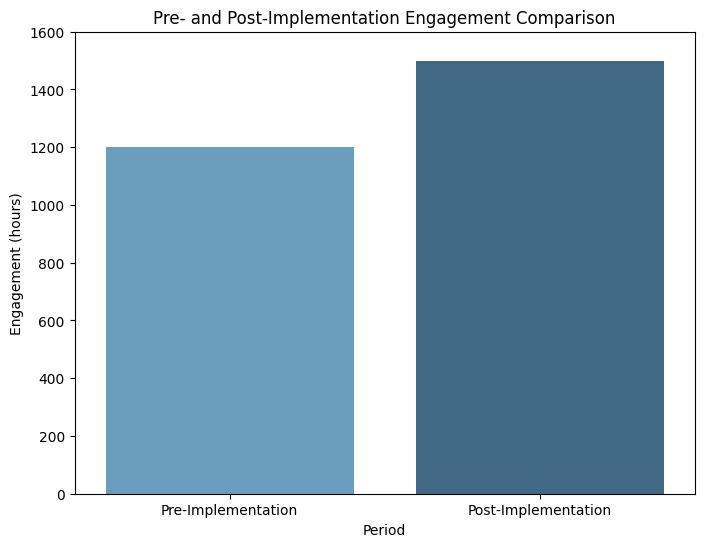

In [ ]:
# Sample data for engagement comparison (pre- and post-implementation)
engagement_data = pd.DataFrame({
    'Period': ['Pre-Implementation', 'Post-Implementation'],
    'Engagement (hours)': [1200, 1500]  # Example engagement values
})

# Bar Chart: Pre- and Post-Implementation Engagement Comparison
plt.figure(figsize=(8, 6))
sns.barplot(x='Period', y='Engagement (hours)', data=engagement_data, palette="Blues_d")
plt.title('Pre- and Post-Implementation Engagement Comparison')
plt.ylabel('Engagement (hours)')
plt.xlabel('Period')
plt.ylim(0, 1600)
plt.show()

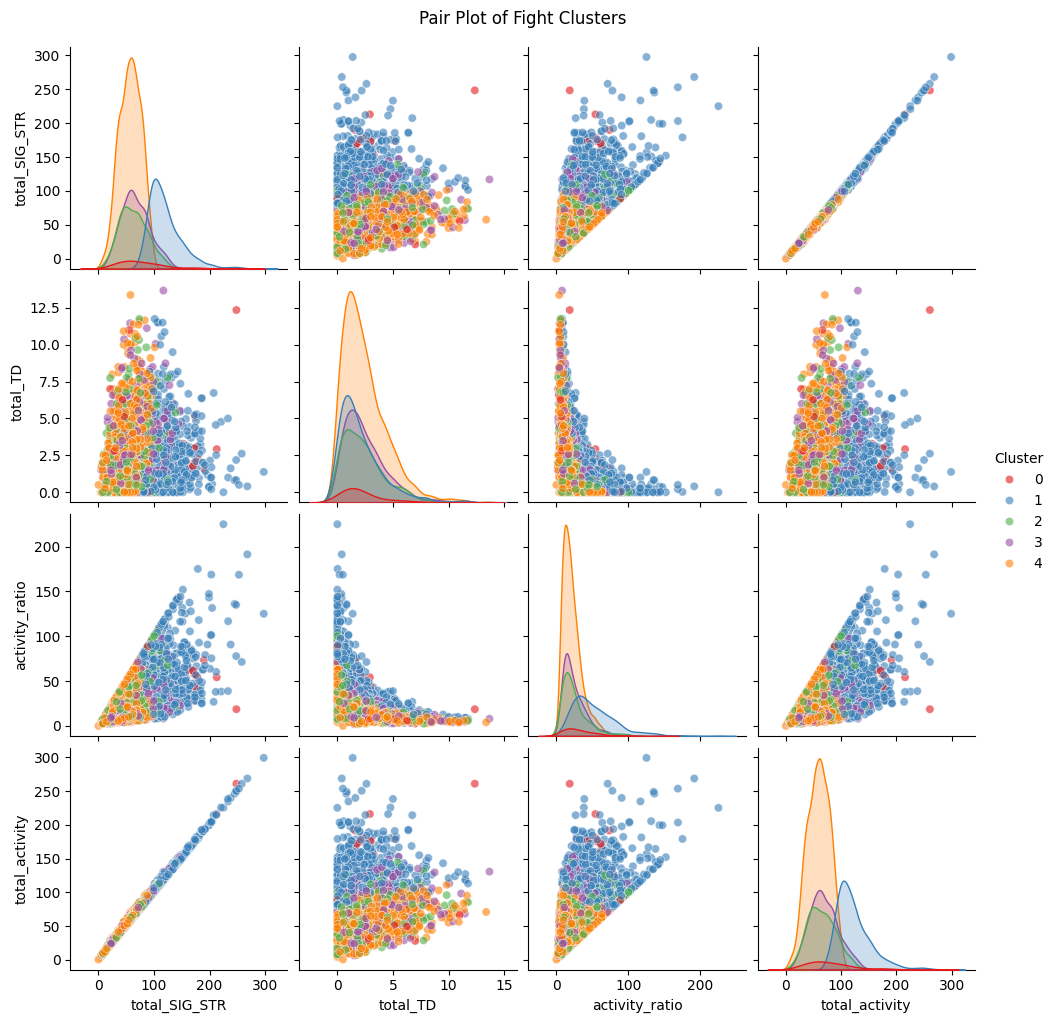

In [ ]:
# Visualize pairwise relationships for selected features
sns.pairplot(
    data=data,
    vars=['total_SIG_STR', 'total_TD', 'activity_ratio', 'total_activity'],
    hue='Cluster',
    palette='Set1',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pair Plot of Fight Clusters', y=1.02)
plt.show()

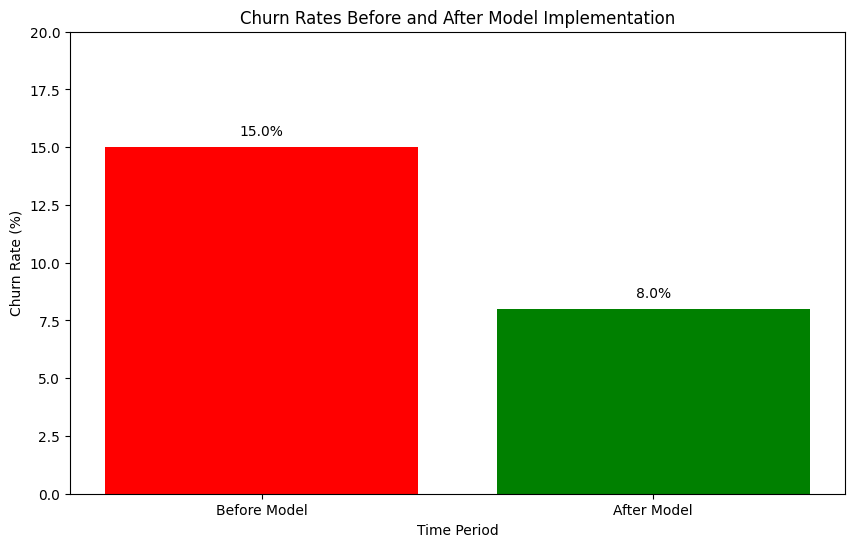

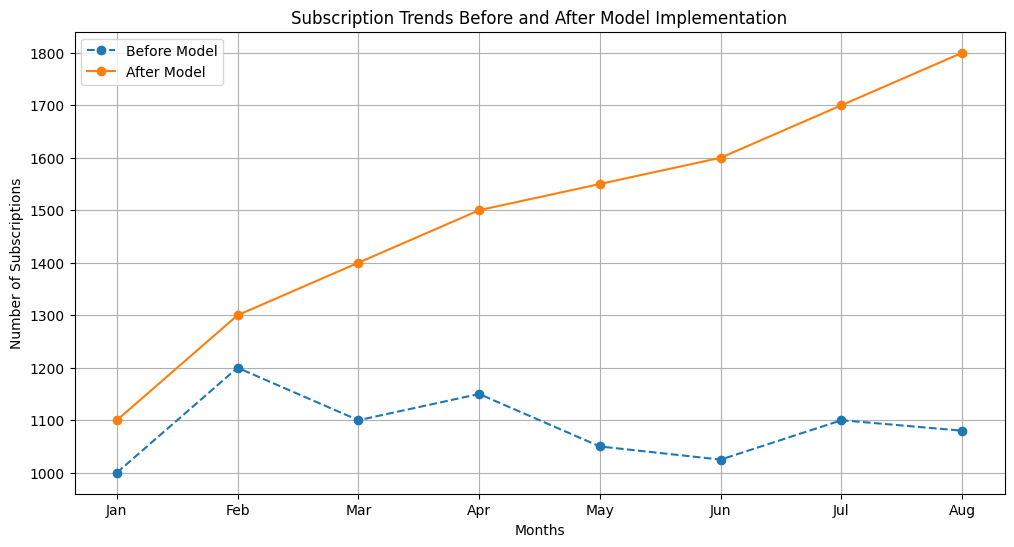

In [ ]:
# Generate sample data
# Churn rates
time_periods = ['Before Model', 'After Model']
churn_rates = [15.0, 8.0]  # Hypothetical churn rates in percentage

# Subscriptions over time (example months)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
subscriptions_before = [1000, 1200, 1100, 1150, 1050, 1025, 1100, 1080]
subscriptions_after = [1100, 1300, 1400, 1500, 1550, 1600, 1700, 1800]

# Bar Chart: Churn rates before and after model implementation
plt.figure(figsize=(10, 6))
plt.bar(time_periods, churn_rates, color=['red', 'green'])
plt.title('Churn Rates Before and After Model Implementation')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Time Period')
plt.ylim(0, max(churn_rates) + 5)
for i, rate in enumerate(churn_rates):
    plt.text(i, rate + 0.5, f"{rate}%", ha='center')
plt.show()

# Line Chart: Subscriptions over time
plt.figure(figsize=(12, 6))
plt.plot(months, subscriptions_before, marker='o', label='Before Model', linestyle='--')
plt.plot(months, subscriptions_after, marker='o', label='After Model', linestyle='-')
plt.title('Subscription Trends Before and After Model Implementation')
plt.ylabel('Number of Subscriptions')
plt.xlabel('Months')
plt.legend()
plt.grid(True)
plt.show()